In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("wildfire.csv")

In [8]:
features = [c for c in df.columns if c not in ['occured', 'frp', 'frp_log']]
X = df[features]
y = df['occured']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_res, y_res)
rf_preds = rf.predict(X_test)
print("RF:", classification_report(y_test, rf_preds))
print("RF AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

RF:               precision    recall  f1-score   support

         0.0       0.68      0.62      0.65     11881
         1.0       0.65      0.71      0.68     11891

    accuracy                           0.67     23772
   macro avg       0.67      0.67      0.67     23772
weighted avg       0.67      0.67      0.67     23772

RF AUC: 0.7339032098869107


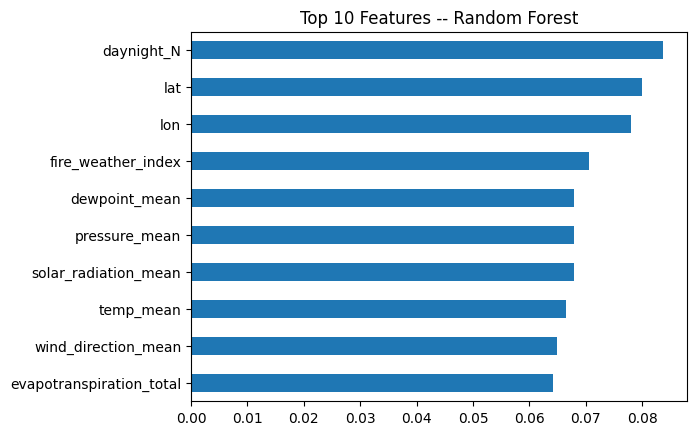

In [10]:
# Feature importance
fi = pd.Series(rf.feature_importances_,
               index=features).sort_values(ascending=False)
fi.head(10).plot(kind='barh').invert_yaxis()
plt.title("Top 10 Features -- Random Forest")
plt.show()

In [11]:
# SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_res)
X_test_sc = scaler.transform(X_test)

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sc, y_res)
svm_preds = svm.predict(X_test_sc)
print("SVM:", classification_report(y_test, svm_preds))

SVM:               precision    recall  f1-score   support

         0.0       0.70      0.50      0.59     11881
         1.0       0.61      0.79      0.69     11891

    accuracy                           0.65     23772
   macro avg       0.66      0.64      0.64     23772
weighted avg       0.66      0.65      0.64     23772



In [12]:
#roc auc
print("SVM AUC:", roc_auc_score(y_test, svm.predict_proba(X_test_sc)[:, 1]))

SVM AUC: 0.6997217579077344
